In [1]:
import os
from xspec import *
import xspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from decimal import Decimal
from scipy import optimize, stats
from iminuit import Minuit
from scipy.stats import chi2 as chi2_scipy


Xset.allowPrompting = False # keeps pyxspec from hanging, waiting for a response to a prompt
Xset.parallel.steppar = 10 # number of threads for steppar


# GOAL: to fit spectra in a window around the line. Use XSpec to fit

I only use 1 power-law+ gaussians. The goal is to check if this works for E>2 keV

Here I load the data 

In [2]:
AllData.clear()
path="/home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/"
filespectrumTM1=path+"srctoolout_120_SourceSpec_00001.fits"
# filespectrumTM1=path+"Rebining_2/srctoolout_120_SourceSpec_00001_2.grp"
fileRMFTM1=path+"srctoolout_120_RMF_00001.fits"
fileARFTM1=path+"srctoolout_120_ARF_00001.fits"
#
filespectrumTM2=path+"srctoolout_220_SourceSpec_00001.fits"
# filespectrumTM2=path+"Rebining_2/srctoolout_220_SourceSpec_00001_2.grp"
fileRMFTM2=path+"srctoolout_220_RMF_00001.fits"
fileARFTM2=path+"srctoolout_220_ARF_00001.fits"
#
filespectrumTM3=path+"srctoolout_320_SourceSpec_00001.fits"
#filespectrumTM3=path+"Rebining_2/srctoolout_320_SourceSpec_00001_2.grp"
fileRMFTM3=path+"srctoolout_320_RMF_00001.fits"
fileARFTM3=path+"srctoolout_320_ARF_00001.fits"
#
filespectrumTM4=path+"srctoolout_420_SourceSpec_00001.fits"
#filespectrumTM4=path+"Rebining_2/srctoolout_420_SourceSpec_00001_2.grp"
fileRMFTM4=path+"srctoolout_420_RMF_00001.fits"
fileARFTM4=path+"srctoolout_420_ARF_00001.fits"
#
filespectrumTM5=path+"srctoolout_520_SourceSpec_00001.fits"
#filespectrumTM5=path+"Rebining_2/srctoolout_520_SourceSpec_00001_2.grp"
fileRMFTM5=path+"srctoolout_520_RMF_00001.fits"
fileARFTM5=path+"srctoolout_520_ARF_00001.fits"
#
filespectrumTM6=path+"srctoolout_620_SourceSpec_00001.fits"
#filespectrumTM6=path+"Rebining_2/srctoolout_620_SourceSpec_00001_2.grp"
fileRMFTM6=path+"srctoolout_620_RMF_00001.fits"
fileARFTM6=path+"srctoolout_620_ARF_00001.fits"
#
filespectrumTM7=path+"srctoolout_720_SourceSpec_00001.fits"
#filespectrumTM7=path+"Rebining_2/srctoolout_720_SourceSpec_00001_2.grp"
fileRMFTM7=path+"srctoolout_720_RMF_00001.fits"
fileARFTM7=path+"srctoolout_720_ARF_00001.fits"
#
#Put here the TM you want to use 
#
vfilespectrum = [filespectrumTM1]#,filespectrumTM2,filespectrumTM3,filespectrumTM4,filespectrumTM6]
vfileRMF = [fileRMFTM1]#,fileRMFTM2,fileRMFTM3,fileRMFTM4,fileRMFTM6]
vfileARF = [fileARFTM1]#,fileARFTM2,fileARFTM3,fileARFTM4,fileARFTM6]
#
#LOAD DATA
#
AllData.clear()
for plot_grp in range (0,len(vfilespectrum)):
    #print("plot_grp ",plot_grp)
    Spectrum(vfilespectrum[plot_grp])
    AllData(plot_grp+1).multiresponse[0] = vfileRMF[plot_grp]
    AllData(plot_grp+1).multiresponse[0].arf = vfileARF[plot_grp]
    AllData(plot_grp+1).multiresponse[1] = vfileRMF[plot_grp] # RMF only for src2

AllData.show()


 response file  read skipped

1 spectrum  in use
 
Spectral Data File: /home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/srctoolout_120_SourceSpec_00001.fits  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.582e+00 +/- 4.115e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: eROSITA Instrument: TM1  Channel Type: PI
  Exposure Time: 9.345e+04 sec
 Using fit statistic: chi
 No response loaded.

***Warning!  One or more spectra are missing responses,
               and are not suitable for fit.
Response successfully loaded.
Arf successfully loaded.
Response successfully loaded.

1 file 1 spectrum 
Spectrum 1  Spectral Data File: /home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/srctoolout_120_SourceSpec_00001.fits
Net count rate (cts/s) for Spectrum:1  1.582e+00 +/- 4.115e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channe

Error: cannot read response file srctoolout_120_RMF_00001.fits


NOW LOAD the Sigma of EROSITA. At the moment I take the FWHM from https://erosita.mpe.mpg.de/edr/eROSITATechnical/calibration.html
Computing \sigma=FWHM/2.355 I find that \sigma ranges from [33,72] eV and E/sigma = [34,139] for E ranging from 1 to 10 keV. 
This is >> sigmav = c/v = 1360 for v=220 km/s.
Larger than intrinsic/Doppler width of astro lines???

In [3]:
data = np.loadtxt("/home/jortecal/GitHub/eRosita/3MLFits/Energy_width.txt",delimiter=",")
vE = data[:,0]
vFWHM = data[:,1]*1e-3 #keV
vsigma = vFWHM/(2.355)

Fix the energy of the DM line and select data

In [4]:
# I do not consider eROSITA data outside this range
Eallmin = 0.3
Eallmax = 9.

Eline = 8.191 #6.266

sigma = np.interp(Eline,vE,vsigma)
print("Eline ",Eline," sigma ",sigma)
Emin= Eline - 5*sigma
Emax= Eline + 5*sigma
if(Emin<Eallmin):
    Emin=Eallmin
if(Emax>Eallmax):
    Emax=Eallmax
print("Emin ",Emin," Emax ",Emax)
str_range = "**-"+str(round(Emin, 4))+",,"+str(round(Emax, 4))+"-**"
print(str_range)
AllData.ignore(str_range)


Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
# Compute number of E bins, assumig it is the same for all TM
NEbins = len(np.asarray(Plot.x(1)))
print("NEbins ",NEbins)
venergies = np.zeros((len(vfilespectrum), NEbins))
vedeltas = np.zeros((len(vfilespectrum), NEbins))
vrates = np.zeros((len(vfilespectrum), NEbins))
verrors = np.zeros((len(vfilespectrum), NEbins))
for i in range (0,len(vfilespectrum)):
    plot_grp = i + 1 # so that it starts with 1
    energiesTMi = np.asarray(Plot.x(plot_grp))
    edeltasTMi = np.asarray(Plot.xErr(plot_grp))
    ratesTMi = np.asarray(Plot.y(plot_grp))
    errorsTMi = np.asarray(Plot.yErr(plot_grp))
    venergies[i] = energiesTMi 
    vedeltas[i] = edeltasTMi 
    vrates[i] = ratesTMi 
    verrors[i] = errorsTMi 
    print("***************")
    print("Selected values ",np.min(energiesTMi)," ",np.max(energiesTMi)," Nbins ",len(energiesTMi))
    print("***************")
    channelmin = AllData(plot_grp).noticed[0] -1
    channelmax = AllData(plot_grp).noticed[-1]
    #print("channelmin/max ",channelmin," ",channelmax)
    #
    SpectrumOpen = fits.open(vfilespectrum[plot_grp-1])['SPECTRUM']
    counts_TMi = SpectrumOpen.data.field('COUNTS')#
    channel_TMi = SpectrumOpen.data.field('CHANNEL')#
    exposure_TMi=fits.getval(vfilespectrum[plot_grp-1],"exposure", ext=1)
    RMFOpen = fits.open(vfileRMF[plot_grp-1])['EBOUNDS']
    Emin_data_TMi = RMFOpen.data.field('E_MIN')#keV
    Emax_data_TMi = RMFOpen.data.field('E_MAX')#keV
    Eave_data_TMi = (Emin_data_TMi+Emax_data_TMi)/2.
    DeltaE_data_TMi = Emax_data_TMi-Emin_data_TMi
    DeltaE_ana_TMi = DeltaE_data_TMi[channelmin:channelmax]
    Eave_ana_TMi = Eave_data_TMi[channelmin:channelmax]
    channel_ana_TMi = channel_TMi[channelmin:channelmax]
    counts_ana_TMi = counts_TMi[channelmin:channelmax]
    print("Min Max counts ",np.min(counts_ana_TMi)," ",np.max(counts_ana_TMi))


Eline  8.191  sigma  0.06378555185584145
Emin  7.872072240720794  Emax  8.509927759279208
**-7.8721,,8.5099-**
Plot command list is now empty
NEbins  44
***************
Selected values  7.886952638626099   8.501469612121582  Nbins  44
***************
   788 channels (1-788) ignored in spectrum #     1
   192 channels (833-1024) ignored in spectrum #     1

Min Max counts  62   108


In [5]:
print("sigma ",sigma)
print("DeltaE ",vedeltas[0]*2)
print("Sigma/DeltaE ",sigma/(vedeltas[0]*2))

sigma  0.06378555185584145
DeltaE  [0.01391745 0.01393366 0.01394796 0.01396561 0.01398134 0.0139966
 0.01401472 0.01402998 0.01404667 0.01406384 0.014081   0.01409721
 0.01411438 0.0141325  0.01414967 0.01416492 0.014184   0.01420116
 0.01421833 0.0142374  0.01425457 0.01427269 0.01429081 0.01430988
 0.014328   0.01434517 0.0143652  0.01438427 0.01440239 0.01442242
 0.01443958 0.01446056 0.01447964 0.01449871 0.01451874 0.01453876
 0.01455784 0.01457787 0.0145998  0.01461887 0.01463985 0.01465988
 0.01468086 0.01470184]
Sigma/DeltaE  [4.58313625 4.57780355 4.57310853 4.56733125 4.56219084 4.55721724
 4.55132516 4.5463752  4.54097351 4.53543086 4.52990172 4.52469211
 4.51918911 4.51339489 4.50791931 4.50306327 4.49700792 4.49157201
 4.48614923 4.48013925 4.47474402 4.46906313 4.46339665 4.45744744
 4.45181036 4.4464831  4.44028406 4.43439626 4.4288173  4.42266738
 4.4174096  4.41100038 4.40518994 4.39939478 4.39332625 4.38727444
 4.38152629 4.37550692 4.36893323 4.36323301 4.35697992 4

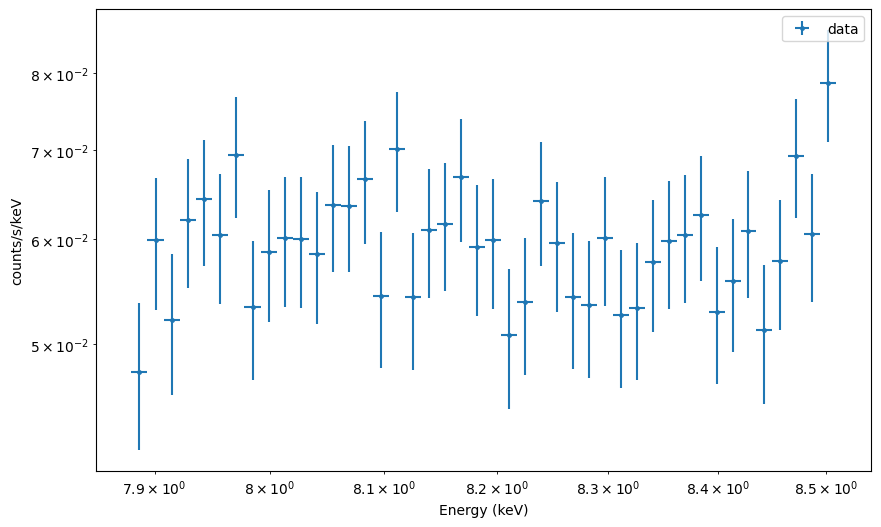

In [6]:
#ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
for i in range (0,len(vfilespectrum)):
    ax.errorbar(venergies[i], vrates[i], xerr=vedeltas[i],yerr=verrors[i],fmt='.',markersize='5',label='data')
#ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Now I consider the Astro and Internal Background lines falling into the energy range +- 7 sigma. At the end I define arrays containing the position of the lines and the min and max values inside which they can fluctuate in the fit


In [7]:
EminL = Eline - 7*sigma
EmaxL = Eline + 7*sigma
if(EminL<Eallmin):
    EminL = Eallmin
if(EmaxL>Eallmax):
    EmaxL = Eallmax

data = np.loadtxt("/home/jortecal/GitHub/eRosita/3MLFits/MarcoFitsMay/IBLines.txt",skiprows=0)
IBenergy = data[:,0]
IBenergymin = data[:,1]
IBenergymax = data[:,2]
data = np.loadtxt("/home/jortecal/GitHub/eRosita/3MLFits/MarcoFitsMay/AstroLines.txt",skiprows=0)
Aenergy = data[:,0]
Aenergymin = data[:,1]
Aenergymax = data[:,2]
#print(Aenergy," ",IBenergy)
#print(len(Aenergy)," ",len(IBenergy))
IBidx = np.where( (IBenergy > EminL ) & (IBenergy < EmaxL ) )
Aidx = np.where( (Aenergy > EminL ) & (Aenergy < EmaxL ) )
IBLine = IBenergy[IBidx]
IBLinemin = IBenergymin[IBidx]
IBLinemax = IBenergymax[IBidx]


ALine = Aenergy[Aidx]
#ALinemin = Aenergymin[Aidx]
#ALinemax = Aenergymax[Aidx]
# SET HERE VARIATION OF ASTRO LINE
AstroEl = 0.005;
ALinemin = ALine - AstroEl
ALinemax = ALine + AstroEl


IBn = len(IBLine)
An = len(ALine)
#
# For this model avoid Astro lines
#
IBALine = IBLine.copy()
IBALinemin = IBLinemin.copy()
IBALinemax = IBLinemax.copy()
IBAn = IBn
idx = np.argsort(IBALine)
IBALine = IBALine[idx]
IBALinemin = IBALinemin[idx]
IBALinemax = IBALinemax[idx]
print("Total lines ",IBAn," IB ",IBn," A ",An)
print(IBALine)
print(IBALinemin," ",IBALinemax)

Total lines  3  IB  3  A  0
[8.06072571 8.21833429 8.61392857]
[7.8  8.15 7.45]   [8.15 8.35 8.75]


FUNCTIONS TO SET LINES TO ZERO AND FIX THEM OR TO FREE THEM

In [8]:
# CLASS TO DEFINE A FUNCTION TO EVALUATE THE TS specified in fit GIVEN A xspec Model model
# with paramers value params, name (gaussian_3, powerlaw,...) params_name and target (norm, LineE,...) params_target

class MTmodel:
    def __init__(self, model, params_name, params_target, fit):
        self.model = model
        self.params_name = params_name
        self.params_target = params_target
        self.fit = fit

        # Precompile fast setters for just the main value (index 0 of .values)
        self._param_fast_setters = [
            self._make_fast_setter(getattr(getattr(model, name), attr))
            for name, attr in zip(params_name, params_target)
        ]

        # Also keep full parameter objects for set_values_all
        self._param_objects = [
            getattr(getattr(model, name), attr)
            for name, attr in zip(params_name, params_target)
        ]

    def _make_fast_setter(self, param_obj):
        def setter(value, param_obj=param_obj):
            #param_obj.values[0] = value
            param_obj.values = value
        return setter

    #set value of parameters
    def set_values(self, params):
        for setter, value in zip(self._param_fast_setters, params):
            setter(float(value))  # direct, fast assignment

    #set value of parameters including upper/lower limits
    def set_values_all(self, params, lowers, uppers):
        for i, param in enumerate(self._param_objects):
            a = float(params[i])
            b = float(lowers[i])
            c = float(uppers[i])
            param.values = [a, 1e-2 * a, b, b, c, c]

    # evaluate TS given paramaters params
    def evaluate_folded(self, params):
        self.set_values(params)
        return self.fit.statistic

    # set a given params_name, params_target to keyfits, i.e. True/False. Relevant for fit with xSpec
    # Careful: my logic is True means is in the fit therefore corresponds to .frozen = False
    def set_frozen(self, keyfits):
        """
        Freeze or unfreeze parameters based on keyfits.
        keyfits[i] == True  → parameter is free (frozen = False)
        keyfits[i] == False → parameter is frozen (frozen = True)
        """
        if len(keyfits) != len(self.params_name):
            raise ValueError("keyfits must be the same length as params_name and params_target")

        for param, keep_free in zip(self._param_objects, keyfits):
            param.frozen = not keep_free  # Invert: True means not frozen

    # return the value of the parameters    
    def get_values(self):
        """Return current values (i.e., param.values[0]) as numpy array."""
        return np.array([param.values[0] for param in self._param_objects])

In [9]:
# Functions working on dictionary

# Given a dictionary model_dic,
# extract all entries as numpy arrays
def Extract_array_dic(model_dic):
    params = []
    lowers = []
    uppers = []
    keyfits = []
    params_name = []
    params_target = []
    for top_key, sub_models in model_dic.items():
        # Skip non-model entries like _structure
        if not isinstance(sub_models, dict):
            continue
        for sub_key, parameters in sub_models.items():
            for paramtarget, param_info in parameters.items():
                params.append(param_info["value"])
                lowers.append(param_info["lower"])
                uppers.append(param_info["upper"])
                keyfits.append(param_info["keyfit"])
                params_name.append(sub_key)     # second-level key (e.g., powerlaw_2)
                params_target.append(paramtarget)     # third-level key (e.g., PhoIndex)

    # Convert everything to NumPy arrays
    params = np.array(params)
    lowers = np.array(lowers)
    uppers = np.array(uppers)
    params_name = np.array(params_name)
    params_target = np.array(params_target)
    keyfits = np.array(keyfits)
    return (params,lowers,uppers,params_name,params_target,keyfits)

In [10]:
# Functions working on numpy arrays

# input arrays defining all the parameters of the model
# output: arrays of parameters entering in the fit (keyfits is True)
def paramfit(params, lowers, uppers , params_name, params_target, keyfits):
    # Create a mask for where keyfits is True
    mask = keyfits == True
    #print(keyfits)
    #print(mask)
    # Apply the mask
    params_out = params[mask]
    lowers_out = lowers[mask]
    uppers_out = uppers[mask]
    params_name_out = params_name[mask]
    params_target_out = params_target[mask]
    keyfits_out = keyfits[mask]
    bounds_out = np.column_stack((lowers_out, uppers_out))
    #print("Values:", params)
    #print("Lowers:", lowers)
    #print("Uppers:", uppers)
    #print("Keyfits:", keyfits)
    #print("Submodel keys:", params_name)
    #print("Param keys:", params_target)
    return (params_out, bounds_out, params_name_out, params_target_out, keyfits_out)

# Select element of params_name, params_target associated to params_name, target_key
# and for that change keyfits to keyfits_value
def change_keyfits(params_name, params_target, keyfits, name_key, target_key, keyfits_value):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask) #True==1
    #print(idx[0]," ",name_key[idx[0]])
    keyfits[idx[0]] = keyfits_value

# For params associated to name_key, target_key change the value to key_value 
def change_param_value(params, params_name, params_target, name_key, target_key, value):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask)
    params[idx[0]] = value

# Return params associated to name_key, target_key
def return_param_value(params, params_name, params_target, name_key, target_key):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask)
    return params[idx[0]]

# Print parameters
def printparam(params, lowers, uppers , params_name, params_target, keyfits):
    for i in range(0,len(params_name)):
        print(params_name[i]," ",params_target[i]," ", params[i]," ", lowers[i]," ", uppers[i]," ", keyfits[i])

Normalization factor (can be useful to define limits of the parameters)

In [11]:
# COMPUTE norm of the line to hit data
# to have an idea of a sensible normalization
# For simplicity choose TM1
arf1test = fits.open(fileARFTM1)['SPECRESP']
arf1ELOW = arf1test.data.field('ENERG_LO')#keV
arf1EHI = arf1test.data.field('ENERG_HI')#keV
arf1Aeff = arf1test.data.field('SPECRESP')#cm2
arf1E = (arf1ELOW + arf1EHI)/2.
Aefftest = np.interp(Eline, arf1E, arf1Aeff)
Ratetest = np.interp(Eline, venergies[0], vrates[0])
normlDMhdata = Ratetest/Aefftest # counts/keV/s/cm2
print("normlDMhdata [counts/keV/s/cm2]",normlDMhdata)
# normlDMhdata2 is the correct normalization to set norm of DM gaussian line to a reasonable value! 
# It has the same units of norm of Gaussian
# See nAPEC_Alll.ipynb
normlDMhdata2 = normlDMhdata*np.sqrt(2*np.pi)*sigma # counts/s/cm2
print("normlDMhdata2 [counts/s/cm2]",normlDMhdata2)


normlDMhdata [counts/keV/s/cm2] 0.8070034022705268
normlDMhdata2 [counts/s/cm2] 0.12902908488809625


Create the dictionary of the model

In [ ]:

# # model 6
# #This is a model based on TBabsorption and APEC phenomenological models
# def pdic(value, lower, upper, key):
#     return {"value": value, "lower": lower, "upper": upper, "keyfit": key}


# normline_start= normlDMhdata2*0.01 #*0.01
# normline_lower = 0.0
# normline_upper = normlDMhdata2*100
# sigmaDM = Eline*220/3e5 #1e-4
# sigma_astrolines = 1e-4
# #
# #
# #power law
# startidx = 3.27 #1.4
# upperidx = 6
# loweridx = - 3
# #
# #startpl = 0.1*normlDMhdata *np.pow(Eline,startidx)
# startpl = 0.05
# upperpl = startpl*1000.0
# lowerpl = 0.0

# #
# # I always define DM to be the first gaussian. I set parameters to False (no in the fit)
# model_dic = {
    
#     "gaussian": {
#         "gaussian": {
#             "norm": pdic(normline_start, normline_lower, normline_upper, False), # (value, lower, upper, key)
#             "LineE" : pdic(Eline, Eline, Eline, False),
#             "Sigma" : pdic(sigmaDM, sigmaDM, sigmaDM, False)
#             }
#         }
#     }
# gaussian_components = [f"gaussian" for i in range(len(IBALine))]
# gaussian_sum = " + ".join(gaussian_components)
# if len(IBALine)>0:
#     model_dic["_structure"] = f"gaussian+ {gaussian_sum}" 
# else:
#     model_dic["_structure"] = f"gaussian"
    
# #ADD gaussian lines
# #
# # Count all second-level keys in the entire model_dic
# # print(model_dic.values())
# start_index_astrol = sum(
#     len(sub_models) for sub_models in model_dic.values()
#     if isinstance(sub_models, dict)
# )
# start_index_astrol = start_index_astrol + 1
# print("start_index_astrol ",start_index_astrol)
# #
# # Start numbering from start_index_astrol to avoid conflict with "gaussian"
# for i in range(len(IBALine)):
#     g_key = f"gaussian_{start_index_astrol + i}"
#     model_dic["gaussian"][g_key] = {
#         "norm": pdic(normline_start, normline_lower, normline_upper, True),
#         "LineE": pdic(IBALine[i], IBALinemin[i], IBALinemax[i], True),
#         "Sigma": pdic(sigma_astrolines, sigma_astrolines, sigma_astrolines, False)
#     }

# model_dic_pb = {
    
#     "powerlaw": {
#         "powerlaw": {
#             "PhoIndex": pdic(startidx, loweridx, upperidx, True), # (value, lower, upper, key)
#             "norm" : pdic(startpl, lowerpl, upperpl, True)
#             }
#         }
#     }


In [12]:
# model 6
#This is a model based on TBabsorption and APEC phenomenological models
def pdic(value, lower, upper, key):
    return {"value": value, "lower": lower, "upper": upper, "keyfit": key}


normline_start= normlDMhdata2*0.01 #*0.01
normline_lower = 0.0
normline_upper = normlDMhdata2*100
sigmaDM = Eline*220/3e5 #1e-4
sigma_astrolines = 1e-4
#
#
#power law
startidx = 3 #1.4
upperidx = 6.0
loweridx = - 3.0
#
#startpl = 0.1*normlDMhdata *np.pow(Eline,startidx)
startpl = 0.05
upperpl = startpl*1000.0
lowerpl = 0.0

#
# I always define DM to be the first gaussian. I set parameters to False (no in the fit)
model_dic = {
    
    "gaussian": {
        "gaussian": {
            "norm": pdic(normline_start, normline_lower, normline_upper, False), # (value, lower, upper, key)
            "LineE" : pdic(Eline, Eline, Eline, False),
            "Sigma" : pdic(sigmaDM, sigmaDM, sigmaDM, False)
            }
        }
    }
# gaussian_components = [f"gaussian" for i in range(len(IBALine))]
# gaussian_sum = " + ".join(gaussian_components)
# if len(IBALine)>0:
#     model_dic["_structure"] = f"gaussian+ {gaussian_sum}" 
# else:
model_dic["_structure"] = f"gaussian"
    
#ADD gaussian lines
#
# Count all second-level keys in the entire model_dic
# print(model_dic.values())
start_index_astrol = sum(
    len(sub_models) for sub_models in model_dic.values()
    if isinstance(sub_models, dict)
)
start_index_astrol = start_index_astrol + 1
print("start_index_astrol ",start_index_astrol)

model_dic_pb = {
    
    "powerlaw": {
        "powerlaw": {
            "PhoIndex": pdic(startidx, loweridx, upperidx, True), # (value, lower, upper, key)
            "norm" : pdic(startpl, lowerpl, upperpl, True)
            }
        },
        "gaussian": {}  # This is the DM line
    }
#
# Start numbering from start_index_astrol to avoid conflict with "gaussian"
for i in range(len(IBALine)):
    if i == 0:
        g_key = "gaussian"
    else:
        g_key = f"gaussian_{i+2}"  # XSPEC adds suffixes starting at _2
    model_dic_pb["gaussian"][g_key] = {
        "norm": pdic(normline_start, normline_lower, normline_upper, True),
        "LineE": pdic(IBALine[i], IBALinemin[i], IBALinemax[i], True),
        "Sigma": pdic(sigma_astrolines, sigma_astrolines, sigma_astrolines, False)
    }



start_index_astrol  2


In [13]:
print(model_dic)
print("******")
print(model_dic_pb)

{'gaussian': {'gaussian': {'norm': {'value': np.float64(0.0012902908488809626), 'lower': 0.0, 'upper': np.float64(12.902908488809626), 'keyfit': False}, 'LineE': {'value': 8.191, 'lower': 8.191, 'upper': 8.191, 'keyfit': False}, 'Sigma': {'value': 0.006006733333333334, 'lower': 0.006006733333333334, 'upper': 0.006006733333333334, 'keyfit': False}}}, '_structure': 'gaussian'}
******
{'powerlaw': {'powerlaw': {'PhoIndex': {'value': 3, 'lower': -3.0, 'upper': 6.0, 'keyfit': True}, 'norm': {'value': 0.05, 'lower': 0.0, 'upper': 50.0, 'keyfit': True}}}, 'gaussian': {'gaussian': {'norm': {'value': np.float64(0.0012902908488809626), 'lower': 0.0, 'upper': np.float64(12.902908488809626), 'keyfit': True}, 'LineE': {'value': np.float64(8.060725714285715), 'lower': np.float64(7.8), 'upper': np.float64(8.15), 'keyfit': True}, 'Sigma': {'value': 0.0001, 'lower': 0.0001, 'upper': 0.0001, 'keyfit': False}}, 'gaussian_3': {'norm': {'value': np.float64(0.0012902908488809626), 'lower': 0.0, 'upper': np.

Define the model

In [ ]:


# # Create the XSpec model
# if "_structure" in model_dic:
#     finalM_xp = model_dic["_structure"]
# else:
#     baseM_parts = []
#     for top_key, sub_models in model_dic.items():
#         count = len(sub_models)
#         baseM_parts.extend([top_key] * count)
#     finalM_xp = '+'.join(baseM_parts)

# print("mw ", finalM_xp)
# AllModels.clear()
# m_mw = Model(finalM_xp, "mw", 1)
# #
# #Add Particle bkg power law
# #
# AllModels += ("powerlaw", "mpb", 2)
# #
# Xset.chatter = 0
# Fit.statMethod = "cstat"
# Fit.nIterations = 10000
# #
# # Extract the relevant info from the model dictionary
# params, lowers, uppers, params_name, params_target, keyfits = Extract_array_dic(model_dic)
# #
# mymodel_mw = MTmodel(model=m_mw, params_name=params_name, params_target=params_target, fit=Fit)
# #
# # Extract the relevant info from the model dictionary of PB
# params_pb, lowers_pb, uppers_pb, params_name_pb, params_target_pb, keyfits_pb = Extract_array_dic(model_dic_pb)
# #
# mymodel_pb = MTmodel(model=AllModels(1,"mpb"), params_name=params_name_pb, params_target=params_target_pb, fit=Fit)
# #
# #
# # set the values including the upper and lower limits in Xspec
# mymodel_mw.set_values_all(params, lowers, uppers)
# # set the free parameters in Xspec
# mymodel_mw.set_frozen(keyfits)
# #
# mymodel_pb.set_values_all(params_pb, lowers_pb, uppers_pb)
# mymodel_pb.set_frozen(keyfits_pb)

In [14]:
if "_structure" in model_dic:
    finalM_xp = model_dic["_structure"]
else:
    baseM_parts = []
    for top_key, sub_models in model_dic.items():
        count = len(sub_models)
        baseM_parts.extend([top_key] * count)
    finalM_xp = '+'.join(baseM_parts)

print("mw ", finalM_xp)
AllModels.clear()
m_mw = Model(finalM_xp, "mw", 1)
#
#Add Particle bkg power law
#
# Build model string: one powerlaw + N gaussian components
n_gauss = len(model_dic_pb["gaussian"])
print("n_gauss ",n_gauss)
model_string_pb = "powerlaw"
if n_gauss > 0:
    model_string_pb += " + " + " + ".join(["gaussian"] * n_gauss)
print("mpb model string:", model_string_pb)
model_dic_pb["_structure"] = model_string_pb
AllModels += (model_string_pb, "mpb", 2)

#
print("MPB model components:", [name for name in dir(AllModels(1, "mpb")) if "gaussian" in name])

Xset.chatter = 0
Fit.statMethod = "cstat"
Fit.nIterations = 100000
#
# Extract the relevant info from the model dictionary
params, lowers, uppers, params_name, params_target, keyfits = Extract_array_dic(model_dic)
#
mymodel_mw = MTmodel(model=m_mw, params_name=params_name, params_target=params_target, fit=Fit)
#
# Extract the relevant info from the model dictionary of PB
params_pb, lowers_pb, uppers_pb, params_name_pb, params_target_pb, keyfits_pb = Extract_array_dic(model_dic_pb)
#
mymodel_pb = MTmodel(model=AllModels(1,"mpb"), params_name=params_name_pb, params_target=params_target_pb, fit=Fit)
#
#
# set the values including the upper and lower limits in Xspec
mymodel_mw.set_values_all(params, lowers, uppers)
# set the free parameters in Xspec
mymodel_mw.set_frozen(keyfits)
#Fit.renorm()
mymodel_pb.set_values_all(params_pb, lowers_pb, uppers_pb)
mymodel_pb.set_frozen(keyfits_pb)

change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", False)
change_param_value(params, params_name, params_target, "gaussian", "norm", 0.0)

# since you have changed norm and key(True/False), update XSpec
mymodel_mw.set_values_all(params, lowers, uppers)
mymodel_mw.set_frozen(keyfits)

# Select the parameters to Fit. You can check that DM is not present
params_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)

printparam(params_fit, bounds_fit[:,0],bounds_fit[:,1], params_name_fit, params_target_fit, keyfits_fit)

mw  gaussian
n_gauss  3
mpb model string: powerlaw + gaussian + gaussian + gaussian
MPB model components: ['gaussian', 'gaussian_3', 'gaussian_4']

Model mw:gaussian<1> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   gaussian   LineE      keV      6.50000      +/-  0.0          
   2    1   gaussian   Sigma      keV      0.100000     +/-  0.0          
   3    1   gaussian   norm                1.00000      +/-  0.0          
________________________________________________________________________


Fit statistic  : Chi-Squared                 3496.00     using 44 bins.

Test statistic : Chi-Squared                 3496.00     using 44 bins.
 Null hypothesis probability of 0.00e+00 with 41 degrees of freedom
 Current data and model not fit yet.

Model mpb:powerlaw<1> + gaussian<2> + gaussian<3> + gaussian<4> Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            1

In [ ]:
#printparam(params, lowers, uppers , params_name, params_target, keyfits)
#print(m_mw.gaussian_2.norm.values)
#printparam(params_pb, lowers_pb, uppers_pb , params_name_pb, params_target_pb, keyfits_pb)

In [15]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 0


Parameters defined:
Model mpb:powerlaw<1> + gaussian<2> + gaussian<3> + gaussian<4> Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            3.00000      +/-  0.0          
   2    1   powerlaw   norm                5.00000E-02  +/-  0.0          
   3    2   gaussian   LineE      keV      8.06073      +/-  0.0          
   4    2   gaussian   Sigma      keV      1.00000E-04  frozen
   5    2   gaussian   norm                1.29029E-03  +/-  0.0          
   6    3   gaussian   LineE      keV      8.21833      +/-  0.0          
   7    3   gaussian   Sigma      keV      1.00000E-04  frozen
   8    3   gaussian   norm                1.29029E-03  +/-  0.0          
   9    4   gaussian   LineE      keV      8.61393      +/-  0.0          
  10    4   gaussian   Sigma      keV      1.00000E-04  frozen
  11    4   gaussian   norm                1.29029E-03  +/-  0.0          
________________________________________

In [ ]:
#print(fullmodel_xp.TBabs.nH.values)
#print(fullmodel_xp.apec.kT.values)
#print(fullmodel_xp.apec.norm.values)
#print(fullmodel_xp.apec.Abundanc.values)
#print(fullmodel_xp.apec.Redshift.values)
#print(fullmodel_xp.powerlaw.PhoIndex.values)
#print(fullmodel_xp.powerlaw.norm.values)
#print(fullmodel_xp.gaussian.norm.values)
#print(fullmodel_xp.gaussian.LineE.values)
#print(fullmodel_xp.gaussian.Sigma.values)
#print(fullmodel_xp.gaussian_5.LineE.values)

In [16]:
printparam(params, lowers, uppers , params_name, params_target, keyfits)
print("****************")
printparam(params_pb, lowers_pb, uppers_pb , params_name_pb, params_target_pb, keyfits_pb)

gaussian   norm   0.0   0.0   12.902908488809626   False
gaussian   LineE   8.191   8.191   8.191   False
gaussian   Sigma   0.006006733333333334   0.006006733333333334   0.006006733333333334   False
****************
powerlaw   PhoIndex   3.0   -3.0   6.0   True
powerlaw   norm   0.05   0.0   50.0   True
gaussian   norm   0.0012902908488809626   0.0   12.902908488809626   True
gaussian   LineE   8.060725714285715   7.8   8.15   True
gaussian   Sigma   0.0001   0.0001   0.0001   False
gaussian_3   norm   0.0012902908488809626   0.0   12.902908488809626   True
gaussian_3   LineE   8.218334285714286   8.15   8.35   True
gaussian_3   Sigma   0.0001   0.0001   0.0001   False
gaussian_4   norm   0.0012902908488809626   0.0   12.902908488809626   True
gaussian_4   LineE   8.613928571428572   7.45   8.75   True
gaussian_4   Sigma   0.0001   0.0001   0.0001   False


In [ ]:
TypeFit = 'XSpec' # 'XSpec', 'Minuit', 'Diffev'

Pre-fit with only power-law

In [ ]:
printparam(params, lowers, uppers , params_name, params_target, keyfits)

In [ ]:
for i in range(len(IBALine)):
        if i == 0:
            namegauss_a = "gaussian"
        else:
            namegauss_a ="gaussian_"+str(start_index_astrol+i)
        # print(namegauss_a)
        #set astrolines to false and zero
        change_keyfits(params_name_pb, params_target_pb, keyfits_pb, namegauss_a, "LineE", False)
        change_keyfits(params_name_pb, params_target_pb, keyfits_pb, namegauss_a, "norm", False)
        change_param_value(params_pb, params_name_pb, params_target_pb, namegauss_a, "norm", 0.0)
    

change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", False)
change_param_value(params, params_name, params_target, "gaussian", "norm", 0.0)
# since you have changed norm and key(True/False), update XSpec
mymodel_mw.set_values_all(params, lowers, uppers)
mymodel_mw.set_frozen(keyfits)
# Select the parameters to Fit. You can check that DM is not present
params_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)
mymodel_pb.set_values_all(params_pb, lowers_pb, uppers_pb)
mymodel_pb.set_frozen(keyfits_pb)
print("**************")
printparam(params_fit, bounds_fit[:,0],bounds_fit[:,1], params_name_fit, params_target_fit, keyfits_fit)

In [ ]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1

In [ ]:
Fit.perform()
Fit.perform()
Fit.perform()

In [ ]:
Xset.chatter = 10
Fit.show()
AllModels.show()
Xset.chatter = 1

Now ....

In [17]:
params_initial = mymodel_pb.get_values()
params_name_initial = mymodel_pb.params_name
params_target_initial = mymodel_pb.params_target
phoindex_inital = return_param_value(params_initial, params_name_initial, params_target_initial, "powerlaw", "PhoIndex")
norm_initial = return_param_value(params_initial, params_name_initial, params_target_initial, "powerlaw", "norm")
print('\n Initial PhoIndex:', phoindex_inital)
for i in range(len(IBALine)):
    if i == 0:
        namegauss_a = "gaussian"
    else:
        
        namegauss_a ="gaussian_"+str(start_index_astrol+i)
    # print(namegauss_a)
    #set astrolines to false and zero
    change_keyfits(params_name_pb, params_target_pb, keyfits_pb, namegauss_a, "LineE", True)
    change_keyfits(params_name_pb, params_target_pb, keyfits_pb, namegauss_a, "norm", True)
    change_param_value(params_pb, params_name_pb, params_target_pb, namegauss_a, "norm", normline_start)

change_param_value(params_pb, params_name_pb, params_target_pb, "powerlaw", "PhoIndex", 3)
change_param_value(params_pb, params_name_pb, params_target_pb, "powerlaw", "norm", norm_initial)
# change_keyfits(params_name_pb, params_target_pb, keyfits_pb, "powerlaw0", "norm", True)


mymodel_pb.set_values_all(params_pb, lowers_pb, uppers_pb)
mymodel_pb.set_frozen(keyfits_pb)



 Initial PhoIndex: 3.0


In [18]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpb:powerlaw<1> + gaussian<2> + gaussian<3> + gaussian<4> Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            3.00000      +/-  0.0          
   2    1   powerlaw   norm                5.00000E-02  +/-  0.0          
   3    2   gaussian   LineE      keV      8.06073      +/-  0.0          
   4    2   gaussian   Sigma      keV      1.00000E-04  frozen
   5    2   gaussian   norm                1.29029E-03  +/-  0.0          
   6    3   gaussian   LineE      keV      8.21833      +/-  0.0          
   7    3   gaussian   Sigma      keV      1.00000E-04  frozen
   8    3   gaussian   norm                1.29029E-03  +/-  0.0          
   9    4   gaussian   LineE      keV      8.61393      +/-  0.0          
  10    4   gaussian   Sigma      keV      1.00000E-04  frozen
  11    4   gaussian   norm                1.29029E-03  +/-  0.0          
________________________________________

Perform Astrofit

In [19]:
#params_astro,TS_astro, pvalue_astro, dof_astro, nfit_astro = doFit(fullmodel_xp, params_fit, bounds_fit, params_name_fit, params_target_fit,TypeFit)

#print("Test Statistics ",TS_astro," testStatistics ",TS_astro," dof ",dof_astro," nVarPars ",nfit_astro)
#print("pvalue ",pvalue_astro)
#printparam(params_astro, bounds_fit[:,0],bounds_fit[:,1], params_name_fit, params_target_fit, keyfits_fit)
Xset.chatter = 10
# Fit.method = "migrad  100000 0" # minimization method = Migrad
Fit.steppar("best mpb:1 -3 6 10  mpb:2 0 15 10")

# Get the parameter grids (these are flattened combinations)
param_grid_1 = np.array(Fit.stepparResults('mpb:1'))  # mpb:1 values for each grid point
param_grid_2 = np.array(Fit.stepparResults('mpb:2'))  # mpb:2 values for each grid point

# Get the fit statistics (same length as param_grid_1 and param_grid_2)
fit_stats = np.array(Fit.stepparResults('statistic'))

# Find the minimum
min_idx = np.argmin(fit_stats)
phoindex_initial = param_grid_1[min_idx]
norm_initial = param_grid_2[min_idx]
min_stat = fit_stats[min_idx]

change_param_value(params_pb, params_name_pb, params_target_pb, "powerlaw", "PhoIndex", phoindex_initial)
change_param_value(params_pb, params_name_pb, params_target_pb, "powerlaw", "norm", norm_initial)

mymodel_pb.set_values_all(params_pb, lowers_pb, uppers_pb)
print(f"Minimum fit statistic: {min_stat} at photon index {phoindex_initial}, normalization {norm_initial}")


     C-Statistic    Delta     mpb:PhoIndex      mpb:norm
                 C-Statistic             1             2

Minimum fit statistic: 27.223051 at photon index 2.4, normalization 9.0
 Due to zero model norms, the following fit parameters are temporarily frozen:131075 131078 131081 
 Due to zero model norms, the following fit parameters are temporarily frozen:131075 131078 131081 
 Due to zero model norms, the following fit parameters are temporarily frozen:131075 131078 131081 
 Due to zero model norms, the following fit parameters are temporarily frozen:131075 131078 131081 
 Due to zero model norms, the following fit parameters are temporarily frozen:131075 131078 131081 
 Due to zero model norms, the following fit parameters are temporarily frozen:131075 131078 131081 
 Due to zero model norms, the following fit parameters are temporarily frozen:131075 131078 131081 
 Due to zero model norms, the following fit parameters are temporarily frozen:131075 131078 131081 
 Due to zero

In [20]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpb:powerlaw<1> + gaussian<2> + gaussian<3> + gaussian<4> Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            2.40000      +/-  0.0          
   2    1   powerlaw   norm                9.00000      +/-  0.0          
   3    2   gaussian   LineE      keV      8.06073      +/-  0.0          
   4    2   gaussian   Sigma      keV      1.00000E-04  +/-  0.0          
   5    2   gaussian   norm                1.29029E-03  +/-  0.0          
   6    3   gaussian   LineE      keV      8.21833      +/-  0.0          
   7    3   gaussian   Sigma      keV      1.00000E-04  +/-  0.0          
   8    3   gaussian   norm                1.29029E-03  +/-  0.0          
   9    4   gaussian   LineE      keV      8.61393      +/-  0.0          
  10    4   gaussian   Sigma      keV      1.00000E-04  +/-  0.0          
  11    4   gaussian   norm                1.29029E-03  +/-  0.0          
____

In [21]:

Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics
Xset.chatter = 1
# Fit.nIterations=500000
Fit.perform()
Fit.perform()
Fit.perform()

In [22]:
Xset.chatter = 10
AllModels.show()
Fit.show()
Xset.chatter = 1



Parameters defined:
Model mpb:powerlaw<1> + gaussian<2> + gaussian<3> + gaussian<4> Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            2.37469      +/-  4.79686      
   2    1   powerlaw   norm                8.03422      +/-  79.9729      
   3    2   gaussian   LineE      keV      8.11007      +/-  7.13057E-02  
   4    2   gaussian   Sigma      keV      1.00000E-04  +/-  -1.00000     
   5    2   gaussian   norm                1.22166E-03  +/-  1.15045E-03  
   6    3   gaussian   LineE      keV      8.33719      +/-  0.160696     
   7    3   gaussian   Sigma      keV      1.00000E-04  +/-  -1.00000     
   8    3   gaussian   norm                9.79560E-04  +/-  2.42421E-03  
   9    4   gaussian   LineE      keV      8.60159      +/-  9.24756E-02  
  10    4   gaussian   Sigma      keV      1.00000E-04  +/-  -1.00000     
  11    4   gaussian   norm                1.04765E-02  +/-  1.01479E-02  
____

In [ ]:
TS_as = Fit.statistic
nfit_as = Fit.nVarPars
dof_as = Fit.dof
pvalue_astro = Fit.nullhyp
params_astro = mymodel_pb.get_values()
params_name_astro = mymodel_pb.params_name
params_target_astro = mymodel_pb.params_target
phoindex_bestfit = return_param_value(params_astro, params_name_astro, params_target_astro, "powerlaw", "PhoIndex")
print("p-value ",chi2_scipy.sf(TS_as, dof_as)," TS ",TS_as)
print("nfit_as ",nfit_as," dof_as ",dof_as)

In [ ]:
#print(chi2_scipy.sf(32.54, 17))
#print(chi2_scipy.sf(32.35, 17))

#print(chi2_scipy.sf(35.34, 17))
#print(chi2_scipy.sf(35.15, 17))

In [ ]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
    ax.plot(energies, foldedmodel,label='model')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

In [ ]:
ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.plot(energies,(rates-foldedmodel)/errors,label='residuals')
#ax.axhline(y=-3)
#ax.axhline(y=3)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r' (data-model)/error')
ax.set_xscale("log")
#ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

In [ ]:
Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)

modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp = i + 1 # so that it starts with 1
    #print(i,plot_grp)
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp))
    modelcomptot = modelcomptot + modelcomp[i]


fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='data',linewidth=3.0)
ax.plot(energiesTMi, foldedmodel,label='model',color='blue')
#ax.plot(energiesTMi, modelcomptot,label='model2',linestyle='-', marker='',color='green',linewidth=3.0)
#
for i in range(0,nAddComps):
#    print(i)
    ax.plot(energiesTMi, modelcomp[i][:],label='',linestyle=':', marker='',color='orange')

ax.plot(energiesTMi, modelcomptot,label='',linestyle='-', marker='',color='green',linewidth=3.0)


ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(np.min(ratesTMi)*0.01,np.max(ratesTMi)*1.5)
ax.grid()
ax.legend()


#data = np.column_stack([energies,modelcomp[1][:], modelcomp[2][:], modelcomp[3][:]])
#datafile_path = "AstroComponents_APEC_APEC_PL.txt"
#np.savetxt(datafile_path , data) #fmt=['%6.2f','%6.2f', '%.2f', '%10.2f', '%10.2f']


In [ ]:
print(modelcomp[0][:])
print(modelcomp[1][:])
print(modelcomp[2][:])
#print(modelcomp[3][:])

NOW FIT ASTRO + DM

In [ ]:
# %%

# NOW FIT ASTRO + DM
# Change DM norm and T/F
change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", True)
change_param_value(params, params_name, params_target, "gaussian", "norm", normline_start)
#
# set the other parameters to their best-fit value of previous fit
for val, name, attr in zip(params_astro, params_name_fit, params_target_fit):
    change_param_value(params, params_name, params_target, name, attr, val)

# since you have changed norm and key(True/False), update XSpec
mymodel_mw.set_values_all(params, lowers, uppers)
mymodel_mw.set_frozen(keyfits)
#
# Select the parameters to Fit. You can check that DM is present
params_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)


Xset.chatter = 10
AllModels.show()
Xset.closeLog()
Xset.chatter = 1

In [ ]:
Fit.perform()
Fit.perform()
Fit.perform()

print("**************** **************** ****************")
Xset.chatter = 10
AllModels.show()
Xset.closeLog()
Xset.chatter = 1



TS_DM = Fit.statistic
nfit_dm = Fit.nVarPars
dof_DM = Fit.dof
pvalue_DM = Fit.nullhyp
params_DM = mymodel_mw.get_values()


DMbf = return_param_value(params_DM , params_name_fit, params_target_fit, "gaussian", "norm")
print("DM bf ",DMbf)
# print("DeltaTS ",TS_astro-TS_DM)

print("Test Statistics DM ",TS_DM," dof ",dof_DM," nVarPars ",nfit_dm)
print("pvalue ",pvalue_DM)

In [ ]:
param_grid_1 = np.array(results[0].paramValues1)
param_grid_2 = np.array(results[0].paramValues2)
fit_stats_2d = np.array(results[0].fitStatistics2D)

min_idx = np.unravel_index(np.argmin(fit_stats_2d), fit_stats_2d.shape)
min_param_1 = param_grid_1[min_idx[0]]
min_param_2 = param_grid_2[min_idx[1]]
min_stat = fit_stats_2d[min_idx]

print(f"Minimum fit statistic: {min_stat} at norm={min_param_1}, PhoIndex={min_param_2}")

    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
    ax.plot(energies, foldedmodel,label='model')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

In [ ]:
Fit.steppar("log mw:3 1e-10 1 50 nolog mpb:2 -2 2 5 mpb:1 -3 6 10 " )


In [ ]:
# Change DM  T/F setting to F
change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", False)
#
# since you have changed norm and key(True/False), update XSpec
mymodel_mw.set_values_all(params, lowers, uppers)
mymodel_mw.set_frozen(keyfits)
#

m_mw.gaussian.norm = .13
pparams_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)


Fit.perform()
Fit.perform()
Fit.perform()


TS_Bound = Fit.statistic
nfit_dm = Fit.nVarPars
dof_DM = Fit.dof
pvalue_DM = Fit.nullhyp
params_DM = mymodel_mw.get_values()


# print("DeltaTS ",TS_astro-TS_DM)

print("Test Statistics DM ",TS_Bound," dof ",dof_DM," nVarPars ",nfit_dm)
print("Delta TS ",TS_Bound-TS_DM)
print("pvalue ",pvalue_DM)

In [ ]:
Xset.chatter = 10
AllModels.show()
Xset.closeLog()
Xset.chatter = 1


In [ ]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
    ax.plot(energies, foldedmodel,label='model')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()